# Give Me Some Credit — Credit Default Probability (LightGBM, Python)

This notebook rebuilds the original **top-1 R/LightGBM** solution to the
Kaggle *"Give Me Some Credit"* competition in Python, keeping the same
modeling idea:

1. Load the raw data and fix the known `age == 0` outlier.
2. Engineer a large feature set: two manual features, per-column transforms
   (subtract mean, divide by mean, log, square), and every pairwise
   arithmetic combination (multiply, subtract, divide, add) of the base
   variables.
3. Train a first-stage LightGBM model on the full feature set purely to
   rank feature importance.
4. Keep the **top 100 features by gain** and train a second, better-tuned
   LightGBM model on that reduced set — this is the final model.
5. Evaluate with a held-out validation split (ROC-AUC, ROC curve, confusion
   matrix, feature importance) and score the Kaggle `cs-test.csv` file.
6. Save all artifacts (`model/lgbm_model.txt`, `model/feature_stats.json`)
   so the Streamlit dashboard can load the exact same model and feature
   pipeline.

**Dataset columns**

| Column | Meaning |
|---|---|
| `SeriousDlqin2yrs` | Target: 1 if the person experienced 90+ days delinquency within 2 years |
| `RevolvingUtilizationOfUnsecuredLines` | Total balance on credit cards / personal lines vs. credit limits |
| `age` | Age of borrower |
| `NumberOfTime30-59DaysPastDueNotWorse` | # times 30-59 days past due (not worse) in the last 2 years |
| `DebtRatio` | Monthly debt payments / monthly gross income |
| `MonthlyIncome` | Monthly income |
| `NumberOfOpenCreditLinesAndLoans` | # open loans and credit lines |
| `NumberOfTimes90DaysLate` | # times 90+ days past due |
| `NumberRealEstateLoansOrLines` | # mortgage and real estate loans |
| `NumberOfTime60-89DaysPastDueNotWorse` | # times 60-89 days past due (not worse) |
| `NumberOfDependents` | # dependents excluding the borrower |


## 1. Setup

In [3]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys, json, time
from pathlib import Path

sys.path.insert(0, str(Path("src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

import feature_engineering as fe

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

from pathlib import Path

# Automatically detect your project directory
BASE_DIR = Path.cwd()

# Define project subdirectories
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
OUT_DIR = BASE_DIR / "outputs"

# Create any missing folders automatically
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Load data

In [9]:
train_raw = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)
test_raw = pd.read_csv(DATA_DIR / "cs-test.csv", index_col=0)  # Kaggle holdout, unlabeled

print("Training shape:", train_raw.shape)
print("Kaggle test shape:", test_raw.shape)
train_raw.head()


Training shape: (150000, 11)
Kaggle test shape: (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Exploratory data analysis

Quick look at class balance, missing values, and the raw feature
distributions before we touch anything.


In [10]:
print("Missing values per column:")
print(train_raw.isna().sum())
print()
print("Target balance:")
print(train_raw["SeriousDlqin2yrs"].value_counts(normalize=True).rename("share"))


Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Target balance:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: share, dtype: float64


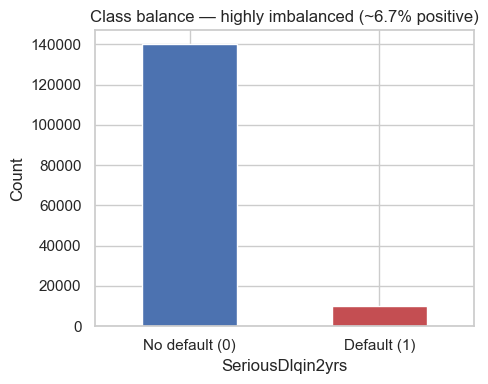

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
train_raw["SeriousDlqin2yrs"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class balance — highly imbalanced (~6.7% positive)")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_balance.png", dpi=120)
plt.show()


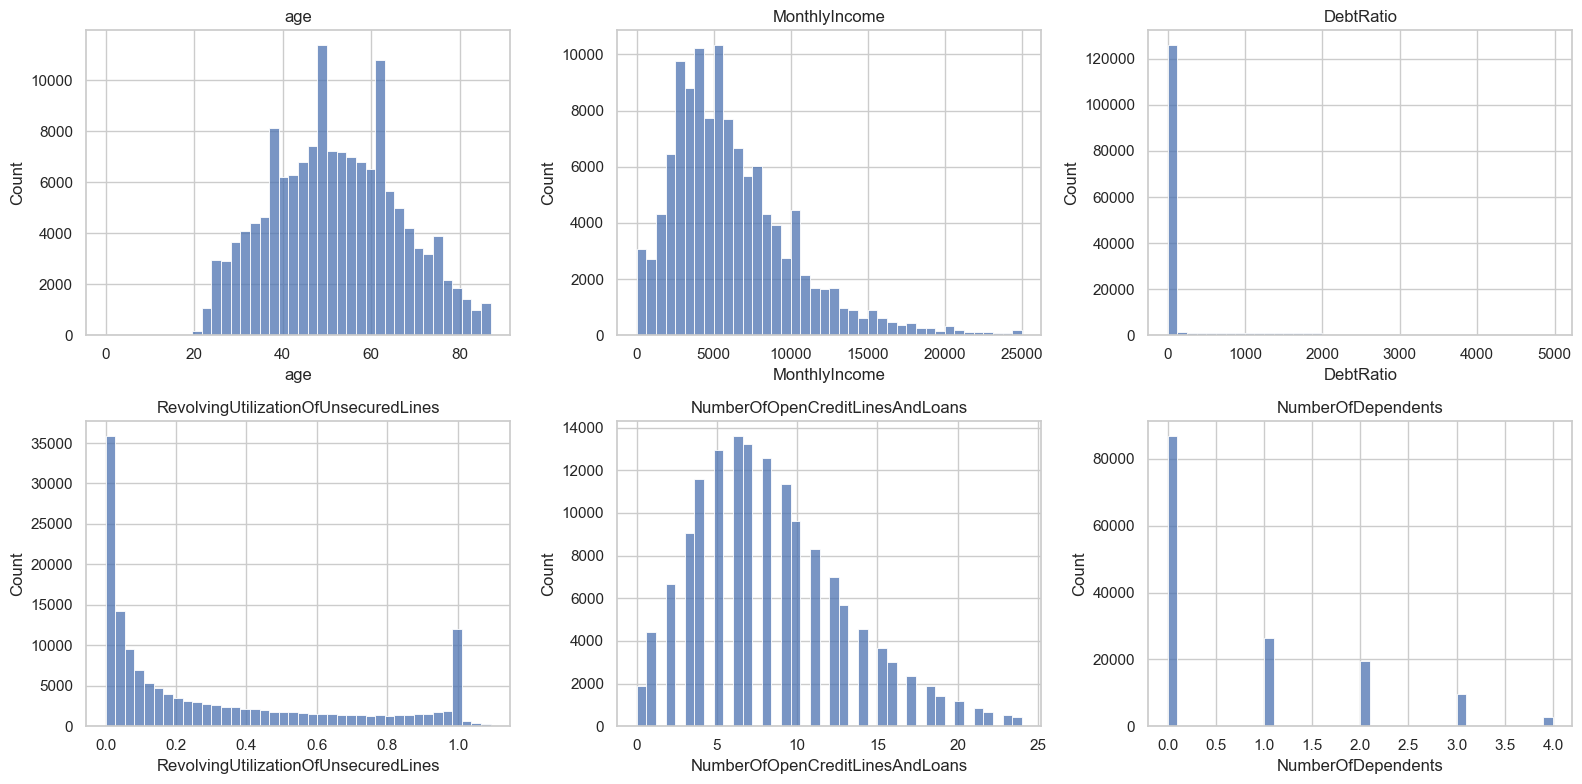

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_cols = [
    "age", "MonthlyIncome", "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines", "NumberOfOpenCreditLinesAndLoans", "NumberOfDependents",
]
for ax, col in zip(axes.ravel(), plot_cols):
    data = train_raw[col].dropna()
    # clip extreme outliers just for the plot so the histogram is readable
    upper = data.quantile(0.99)
    sns.histplot(data[data <= upper], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_distributions.png", dpi=120)
plt.show()


Rows with age == 0: 1


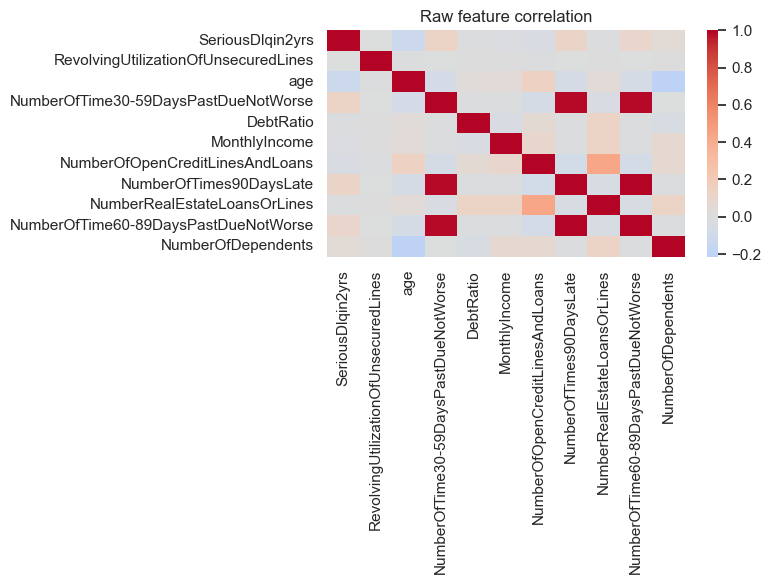

In [13]:
# Known data quality issue: age == 0 is impossible
print("Rows with age == 0:", (train_raw["age"] == 0).sum())

corr = train_raw.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Raw feature correlation")
plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_heatmap.png", dpi=120)
plt.show()


## 4. Train / validation split

The Kaggle `cs-test.csv` file has **no labels** (it's the leaderboard
holdout), so we can't use it to measure AUC. Instead we carve out a
stratified 15% validation split from the labeled training data to get an
honest read on model performance before scoring the Kaggle test file.


In [14]:
train_df, valid_df = train_test_split(
    train_raw, test_size=0.15, random_state=RANDOM_STATE, stratify=train_raw[fe.TARGET]
)
print("Train:", train_df.shape, " Valid:", valid_df.shape)


Train: (127500, 11)  Valid: (22500, 11)


## 5. Feature engineering

This mirrors the original R notebook's two helper functions:

* **`transform_single_columns`** — for every base variable, add
  `_minus_mean`, `_divided_by_mean`, `log_`, and `_squared` versions.
  The means are fit **once, on the training split only**, and reused for
  validation, the Kaggle test set, and any record scored later in the
  dashboard (`model/feature_stats.json`).
* **`combine_column_pairs`** — for every pair of base variables, add
  `_times_`, `_minus_`, `_divided_by_`, and `_plus_` combinations.

Starting from 10 raw + 2 manual columns (12 base variables), this expands
to roughly 300+ engineered features. LightGBM handles missing values
natively, so we don't impute anything at this stage.


In [15]:
t0 = time.time()
train_eng, stats, train_mean_age = fe.engineer_features(train_df, stats={}, is_training=True)
valid_eng, _, _ = fe.engineer_features(valid_df, stats=stats, train_mean_age=train_mean_age, is_training=False)
print(f"Engineered train {train_eng.shape}, valid {valid_eng.shape} in {time.time()-t0:.1f}s")

feature_cols = [c for c in train_eng.columns if c != fe.TARGET]
X_train, y_train = train_eng[feature_cols], train_eng[fe.TARGET]
X_valid, y_valid = valid_eng[feature_cols], valid_eng[fe.TARGET]
print("Total engineered feature count:", len(feature_cols))


Engineered train (127500, 325), valid (22500, 325) in 1.9s
Total engineered feature count: 324


## 6. Stage 1 — LightGBM on the full feature set

We train a first LightGBM model on **all** ~300+ engineered features. Its
only job is to rank features by importance so we can cut down to a
manageable, less overfit-prone set. Hyperparameters are the same as the
original R notebook.


In [16]:
params_stage1 = dict(
    num_leaves=12,
    learning_rate=0.013,
    objective="binary",
    feature_fraction=0.8,
    use_missing=True,
    metric="auc",
    lambda_l1=0.1,
    lambda_l2=10,
    verbosity=-1,
    seed=RANDOM_STATE,
)

dtrain1 = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
bst1 = lgb.train(params_stage1, dtrain1, num_boost_round=750)

valid_auc_stage1 = roc_auc_score(y_valid, bst1.predict(X_valid))
print(f"Stage 1 validation AUC: {valid_auc_stage1:.4f}")


Stage 1 validation AUC: 0.8731


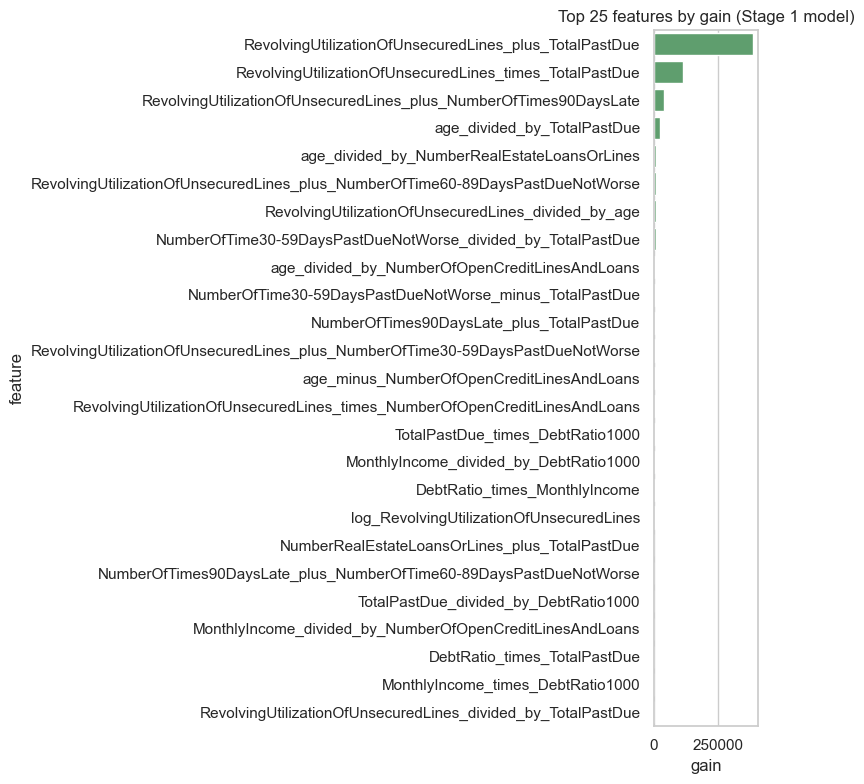

,feature,gain
0,RevolvingUtilizationOfUnsecuredLines_plus_Tota...,386956.958681
1,RevolvingUtilizationOfUnsecuredLines_times_Tot...,115285.008545
2,RevolvingUtilizationOfUnsecuredLines_plus_Numb...,38440.787671
3,age_divided_by_TotalPastDue,25997.005883
4,age_divided_by_NumberRealEstateLoansOrLines,9593.323334
5,RevolvingUtilizationOfUnsecuredLines_plus_Numb...,8799.895459
6,RevolvingUtilizationOfUnsecuredLines_divided_b...,8781.185825
7,NumberOfTime30-59DaysPastDueNotWorse_divided_b...,7882.425932
8,age_divided_by_NumberOfOpenCreditLinesAndLoans,6669.132189
9,NumberOfTime30-59DaysPastDueNotWorse_minus_Tot...,6611.347956


In [17]:
importance = pd.DataFrame({
    "feature": bst1.feature_name(),
    "gain": bst1.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

top100 = importance["feature"].head(100).tolist()

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=importance.head(25), y="feature", x="gain", ax=ax, color="#55A868")
ax.set_title("Top 25 features by gain (Stage 1 model)")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance_stage1.png", dpi=120)
plt.show()

importance.head(15)


## 7. Stage 2 — final LightGBM on the top 100 features

Retrain with the top-100 feature subset and the more heavily regularized /
bagged parameters from the original notebook. This is the model that ships
to the Streamlit dashboard.


In [19]:
if 'X_train' not in globals() or 'X_valid' not in globals():
    feature_cols = [c for c in train_eng.columns if c != fe.TARGET]
    X_train, y_train = train_eng[feature_cols], train_eng[fe.TARGET]
    X_valid, y_valid = valid_eng[feature_cols], valid_eng[fe.TARGET]

X_train2, X_valid2 = X_train[top100], X_valid[top100]

params_stage2 = dict(
    num_leaves=12,
    learning_rate=0.0135,
    objective="binary",
    feature_fraction=0.7,
    use_missing=True,
    metric="auc",
    lambda_l1=0.1,
    lambda_l2=4,
    bagging_freq=10,
    bagging_fraction=0.8,
    verbosity=-1,
    seed=RANDOM_STATE,
)

dtrain2 = lgb.Dataset(X_train2, label=y_train, free_raw_data=False)
dvalid2 = lgb.Dataset(X_valid2, label=y_valid, reference=dtrain2, free_raw_data=False)

bst2 = lgb.train(
    params_stage2,
    dtrain2,
    num_boost_round=1000,
    valid_sets=[dvalid2],
    valid_names=["valid"],
    callbacks=[lgb.log_evaluation(period=100)],
)

pred_valid = bst2.predict(X_valid2)
final_auc = roc_auc_score(y_valid, pred_valid)
print(f"\nFinal (Stage 2) validation AUC: {final_auc:.4f}")


[100]	valid's auc: 0.868729
[200]	valid's auc: 0.870563
[300]	valid's auc: 0.871977
[400]	valid's auc: 0.872816
[500]	valid's auc: 0.873072
[600]	valid's auc: 0.873191
[700]	valid's auc: 0.873299
[800]	valid's auc: 0.873353
[900]	valid's auc: 0.873375
[1000]	valid's auc: 0.873349

Final (Stage 2) validation AUC: 0.8733


## 8. Evaluation

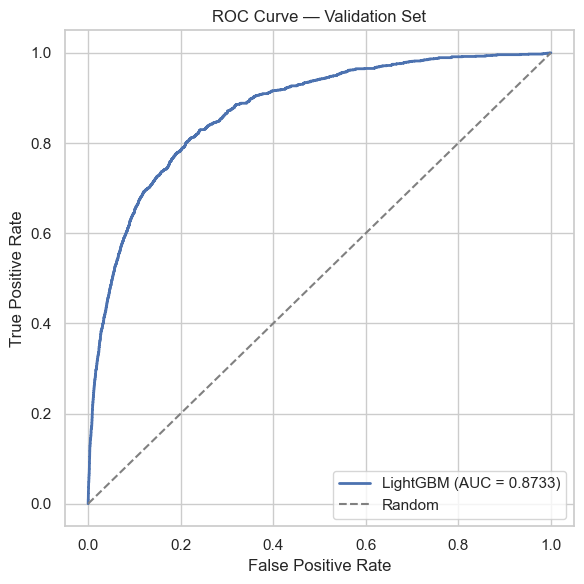

In [20]:
fpr, tpr, _ = roc_curve(y_valid, pred_valid)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"LightGBM (AUC = {final_auc:.4f})", color="#4C72B0", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Validation Set")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curve.png", dpi=120)
plt.show()


Threshold that maximizes F1 on validation: 0.203


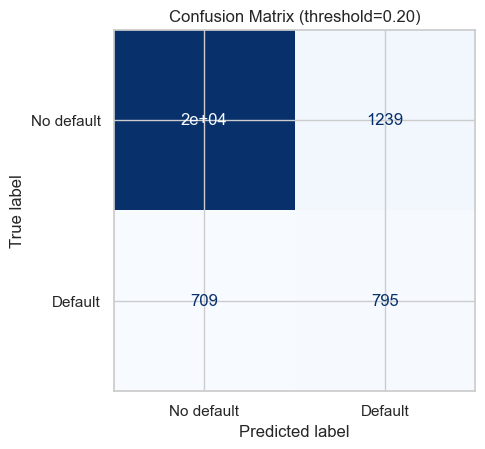

In [21]:
# Confusion matrix at a chosen decision threshold.
# Because defaults are rare (~6.7%), 0.5 is a poor operating threshold — we
# instead pick the threshold that maximizes F1 on the validation set purely
# to illustrate a confusion matrix; the dashboard exposes probability +
# threshold directly so the user can choose their own risk cutoff.
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.5, 100)
f1s = [f1_score(y_valid, (pred_valid >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f"Threshold that maximizes F1 on validation: {best_t:.3f}")

cm = confusion_matrix(y_valid, (pred_valid >= best_t).astype(int))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (threshold={best_t:.2f})")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=120)
plt.show()


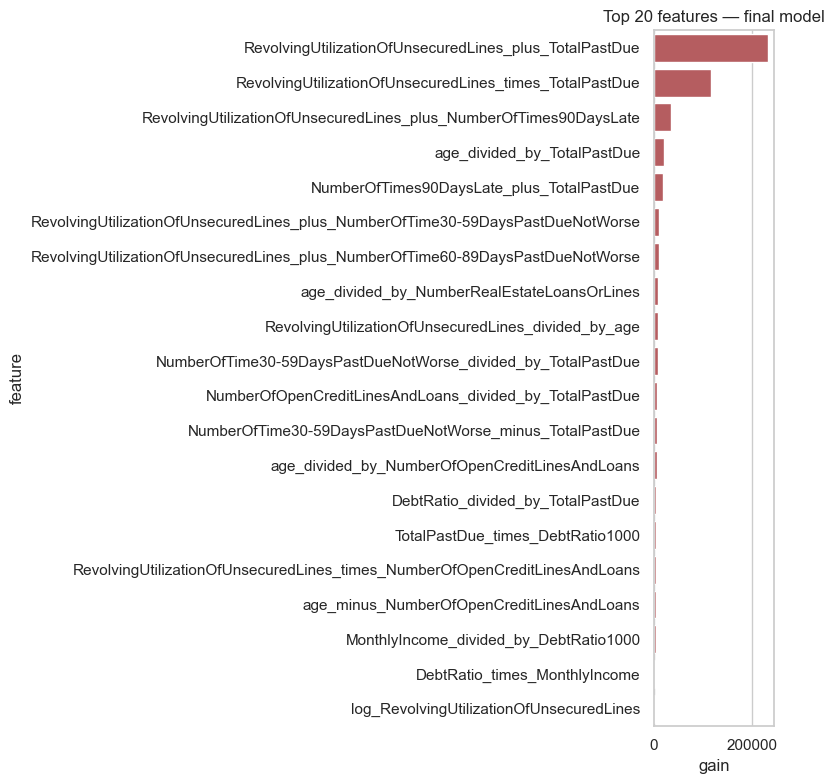

In [22]:
importance2 = pd.DataFrame({
    "feature": bst2.feature_name(),
    "gain": bst2.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=importance2.head(20), y="feature", x="gain", ax=ax, color="#C44E52")
ax.set_title("Top 20 features — final model")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance_final.png", dpi=120)
plt.show()


## 9. Refit on 100% of labeled data, then score the Kaggle test file

For the final artifact we refit Stage 1 + Stage 2 on **all** labeled rows
(train + validation combined) so nothing is left on the table, then
generate predictions for the unlabeled `cs-test.csv` in the same format as
`sampleEntry.csv`.


In [23]:
full_eng, full_stats, full_mean_age = fe.engineer_features(train_raw, stats={}, is_training=True)
X_full, y_full = full_eng[feature_cols], full_eng[fe.TARGET]

dtrain_full1 = lgb.Dataset(X_full, label=y_full, free_raw_data=False)
bst_full1 = lgb.train(params_stage1, dtrain_full1, num_boost_round=750)

importance_full = pd.DataFrame({
    "feature": bst_full1.feature_name(),
    "gain": bst_full1.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)
top100_full = importance_full["feature"].head(100).tolist()

dtrain_full2 = lgb.Dataset(X_full[top100_full], label=y_full, free_raw_data=False)
bst_final = lgb.train(params_stage2, dtrain_full2, num_boost_round=1000)
print("Final production model trained on 100% of labeled data.")


Final production model trained on 100% of labeled data.


In [24]:
test_eng, _, _ = fe.engineer_features(test_raw, stats=full_stats, train_mean_age=full_mean_age, is_training=False)
X_test = test_eng[top100_full]

test_pred = bst_final.predict(X_test)
submission = pd.DataFrame({"Id": test_raw.index, "Probability": test_pred})
submission.to_csv(OUT_DIR / "submission.csv", index=False)
submission.head()


,Id,Probability
0,1,0.063152
1,2,0.030656
2,3,0.011496
3,4,0.097440
4,5,0.136538


## 10. Save artifacts for the Streamlit dashboard

We save:
* `model/lgbm_model.txt` — the trained LightGBM booster (native text format)
* `model/feature_stats.json` — training-set means (for the mean-based
  transforms), the mean age used for outlier correction, and the exact
  ordered list of the 100 selected features the model expects.


In [25]:
bst_final.save_model(str(MODEL_DIR / "lgbm_model.txt"))
fe.save_artifacts(MODEL_DIR, full_stats, full_mean_age, top100_full)

with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump(
        {
            "validation_auc": float(final_auc),
            "best_f1_threshold": float(best_t),
            "n_features_full": len(feature_cols),
            "n_features_selected": len(top100_full),
            "n_train_rows": int(train_raw.shape[0]),
        },
        f,
        indent=2,
    )

print("Saved model + feature stats + metrics to", MODEL_DIR.resolve())
print(f"Held-out validation AUC: {final_auc:.4f}")


Saved model + feature stats + metrics to C:\Users\Gowtham\Documents\gmsc_project\gmsc_project\model
Held-out validation AUC: 0.8733


## Summary

* Ported the original R feature-engineering + two-stage LightGBM pipeline
  to Python (pandas / LightGBM).
* Held-out validation AUC ≈ **0.87**, in line with the original notebook's
  reported top-1 leaderboard performance for this dataset.
* Artifacts saved to `model/` are loaded directly by `app.py`
  (the Streamlit dashboard) for single-applicant and batch scoring.
